# CONUS2 flow barrier layer map

For each horizontal cell, find the **topmost** model layer (ParFlow `z` index, 0 = bottom, 9 = top) where `pf_flowbarrier < 0.5` (barrier value ~0.001). Cells with no barrier in the column are masked.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap
from parflow.tools.io import read_pfb

DATA_DIR = Path("/glade/derecho/scratch/bwest/drought-ensemble/analysis/conus2_flow_barrier_z")
PFB_PATH = DATA_DIR / "pf_flowbarrier.pfb"
OUTPUT_PATH = DATA_DIR / "flow_barrier_layer_map.png"

NZ = 10  # CONUS2 layers (index 0 = bottom, 9 = top)

In [2]:
flowbarrier = read_pfb(PFB_PATH)
print("shape (nz, ny, nx):", flowbarrier.shape)

# Active domain: positive values in layer 0; barrier cells use ~0.001 vs 1.0 elsewhere
active = np.isfinite(flowbarrier[0]) & (flowbarrier[0] > 0)
is_barrier = active[None, ...] & (flowbarrier > 0) & (flowbarrier < 0.5)

layer_ids = np.arange(flowbarrier.shape[0], dtype=np.int16)[:, None, None]
barrier_layer = np.where(is_barrier, layer_ids, -1).max(axis=0).astype(np.float32)
barrier_layer[barrier_layer < 0] = np.nan  # no barrier in column

print(f"active cells: {active.sum():,}")
print(f"columns with a barrier: {np.isfinite(barrier_layer).sum():,}")
print(
    "layer index range:",
    int(np.nanmin(barrier_layer)),
    "to",
    int(np.nanmax(barrier_layer)),
)

shape (nz, ny, nx): (10, 3256, 4442)
active cells: 7,848,641
columns with a barrier: 7,831,110
layer index range: 1 to 6


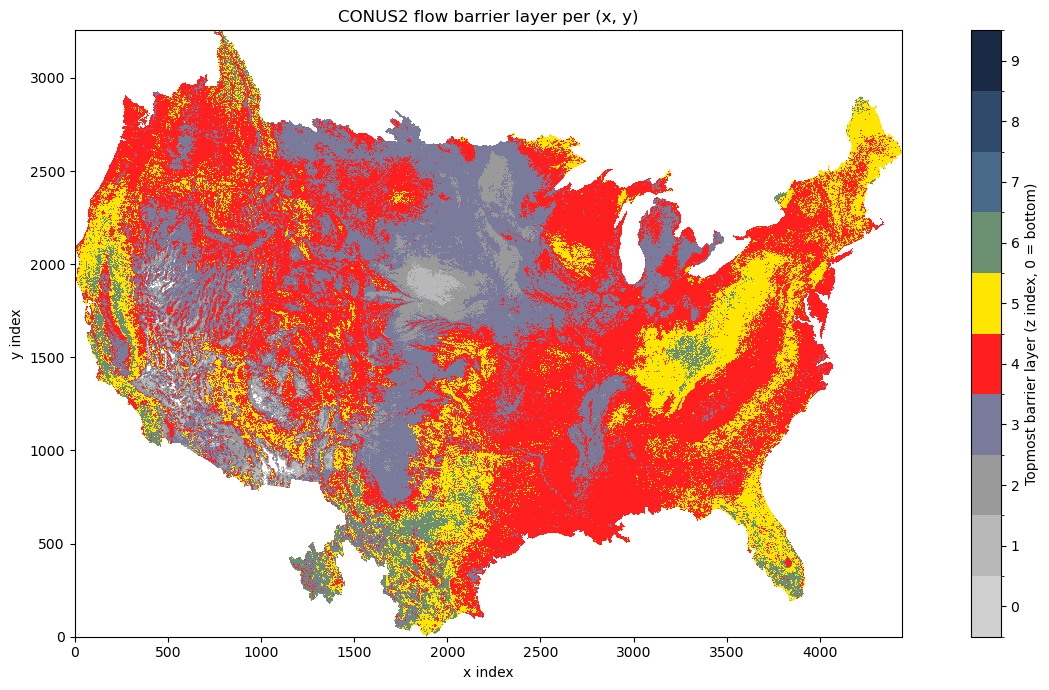

Saved /glade/derecho/scratch/bwest/drought-ensemble/analysis/conus2_flow_barrier_z/flow_barrier_layer_map.png


In [3]:
layer_vals = np.arange(NZ)
# Muted colors for other layers; layers 4 and 5 are high-contrast highlights
layer_colors = [
    "#d0d0d0",  # 0
    "#b8b8b8",  # 1
    "#9a9a9a",  # 2
    "#7a7a9a",  # 3
    "#ff1f1f",  # 4 — stand out
    "#ffe600",  # 5 — stand out
    "#6a8f71",  # 6
    "#4a6a8a",  # 7
    "#2f4a6a",  # 8
    "#1a2a44",  # 9
]
cmap = ListedColormap(layer_colors)
norm = BoundaryNorm(np.arange(NZ + 1) - 0.5, NZ)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(
    barrier_layer,
    origin="lower",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)
cbar = fig.colorbar(im, ax=ax, ticks=layer_vals)
cbar.set_label("Topmost barrier layer (z index, 0 = bottom)")
ax.set_title("CONUS2 flow barrier layer per (x, y)")
ax.set_xlabel("x index")
ax.set_ylabel("y index")
plt.tight_layout()
fig.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_PATH}")

/glade/derecho/scratch/bwest/tmp/ipykernel_93785/2066294695.py:6: RuntimeWarning: All-NaN slice encountered
  flowbarrier_value = np.nanmin(


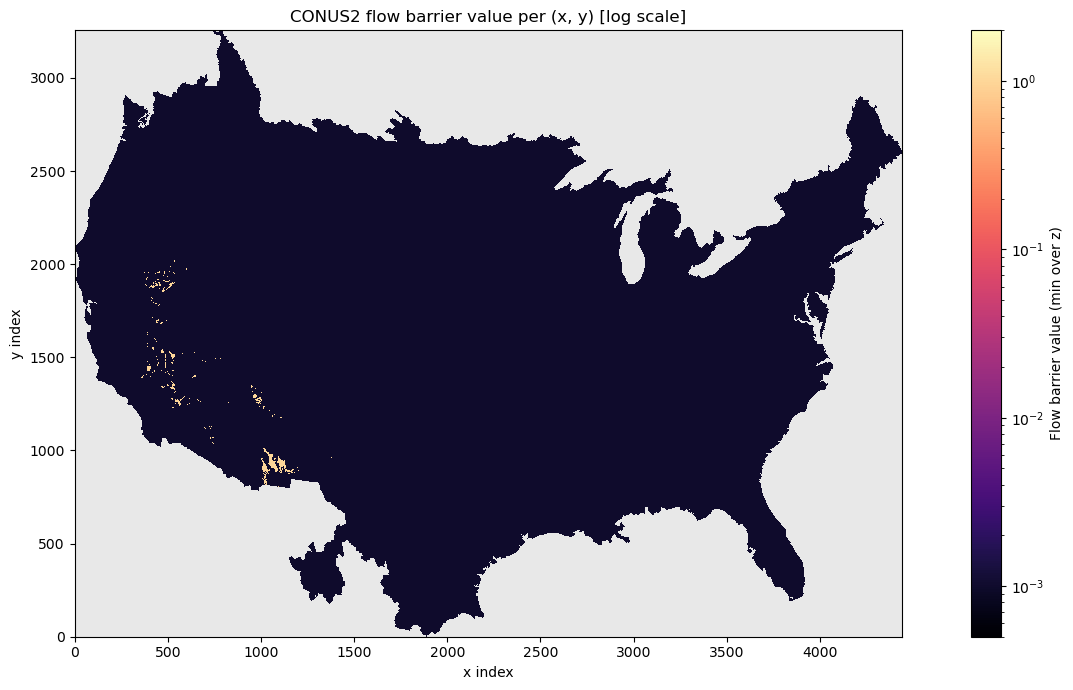

Saved /glade/derecho/scratch/bwest/drought-ensemble/analysis/conus2_flow_barrier_z/flow_barrier_value_map.png
unique values: [0.001 1.   ]


In [4]:
from matplotlib.colors import LogNorm

VALUE_OUTPUT_PATH = DATA_DIR / "flow_barrier_value_map.png"

# Minimum over z: 0.001 where any layer has a barrier, 1.0 where the column is fully open
flowbarrier_value = np.nanmin(
    np.where(active[None, :, :], flowbarrier, np.nan),
    axis=0,
)

fig, ax = plt.subplots(figsize=(14, 7))
value_cmap = plt.cm.magma.copy()
value_cmap.set_bad("#e8e8e8")  # outside active domain

im = ax.imshow(
    flowbarrier_value,
    origin="lower",
    cmap=value_cmap,
    norm=LogNorm(vmin=5e-4, vmax=2.0),
    interpolation="nearest",
)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Flow barrier value (min over z)")
ax.set_title("CONUS2 flow barrier value per (x, y) [log scale]")
ax.set_xlabel("x index")
ax.set_ylabel("y index")
plt.tight_layout()
fig.savefig(VALUE_OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {VALUE_OUTPUT_PATH}")
print("unique values:", np.unique(flowbarrier_value[np.isfinite(flowbarrier_value)]))

## Depth to flow barrier

Convert the topmost barrier layer index to **depth below land surface** using CONUS2 layer thicknesses (`DZ_Multiplier × 200 m`; 392 m total column depth).

In [9]:
# CONUS2 DZ multipliers (index 0 = bottom, 9 = top); thickness = multiplier × 200 m
DZ_MULTIPLIERS = np.array([1.0, 0.5, 0.25, 0.125, 0.05, 0.025, 0.005, 0.003, 0.0015, 0.0005])
dz = DZ_MULTIPLIERS * 200.0

# Depth from surface to the top of layer k (sum of all layers above k)
depth_to_layer_top = np.array([dz[i + 1 :].sum() for i in range(NZ)])

barrier_layer_int = np.full(barrier_layer.shape, -1, dtype=np.int16)
valid_barrier = np.isfinite(barrier_layer)
barrier_layer_int[valid_barrier] = barrier_layer[valid_barrier].astype(np.int16)

barrier_depth = np.full_like(barrier_layer, np.nan, dtype=np.float32)
has_barrier = barrier_layer_int >= 0
barrier_depth[has_barrier] = depth_to_layer_top[barrier_layer_int[has_barrier]]
barrier_depth_cm = barrier_depth * 100.0

print("layer thicknesses (m), bottom → top:")
for i, (mult, thick) in enumerate(zip(DZ_MULTIPLIERS, dz)):
    print(f"  z={i:2d}: multiplier={mult:g}, dz={thick:g} m")
print(f"total column depth: {dz.sum():g} m")
print()
print("depth to barrier:", np.nanmin(barrier_depth_cm), "to", np.nanmax(barrier_depth_cm), "cm")

layer thicknesses (m), bottom → top:
  z= 0: multiplier=1, dz=200 m
  z= 1: multiplier=0.5, dz=100 m
  z= 2: multiplier=0.25, dz=50 m
  z= 3: multiplier=0.125, dz=25 m
  z= 4: multiplier=0.05, dz=10 m
  z= 5: multiplier=0.025, dz=5 m
  z= 6: multiplier=0.005, dz=1 m
  z= 7: multiplier=0.003, dz=0.6 m
  z= 8: multiplier=0.0015, dz=0.3 m
  z= 9: multiplier=0.0005, dz=0.1 m
total column depth: 392 m

depth to barrier: 100.0 to 9200.0 cm


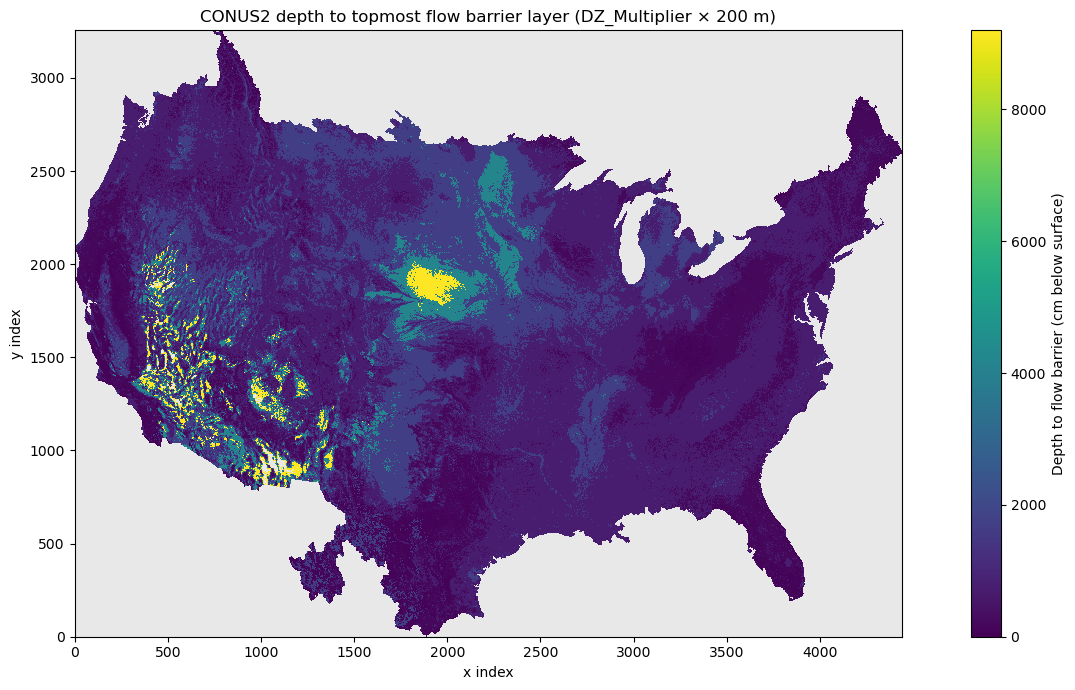

Saved /glade/derecho/scratch/bwest/drought-ensemble/analysis/conus2_flow_barrier_z/flow_barrier_depth_map.png


In [10]:
DEPTH_OUTPUT_PATH = DATA_DIR / "flow_barrier_depth_map.png"

depth_cmap = plt.cm.viridis.copy()
depth_cmap.set_bad("#e8e8e8")

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(
    barrier_depth_cm,
    origin="lower",
    cmap=depth_cmap,
    vmin=0.0,
    vmax=float(np.nanmax(barrier_depth_cm)),
    interpolation="nearest",
)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Depth to flow barrier (cm below surface)")
ax.set_title("CONUS2 depth to topmost flow barrier layer (DZ_Multiplier × 200 m)")
ax.set_xlabel("x index")
ax.set_ylabel("y index")
plt.tight_layout()
fig.savefig(DEPTH_OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {DEPTH_OUTPUT_PATH}")

In [11]:
## Depth to bedrock distribution

Histogram of calculated depth to bedrock across all active CONUS2 cells with a flow barrier.

SyntaxError: invalid syntax (1610571176.py, line 3)

  100 cm: 357,752 cells
  200 cm: 1,288,351 cells
  700 cm: 3,755,153 cells
  1700 cm: 1,915,946 cells
  4200 cm: 399,526 cells
  9200 cm: 114,382 cells
total cells with bedrock: 7,831,110


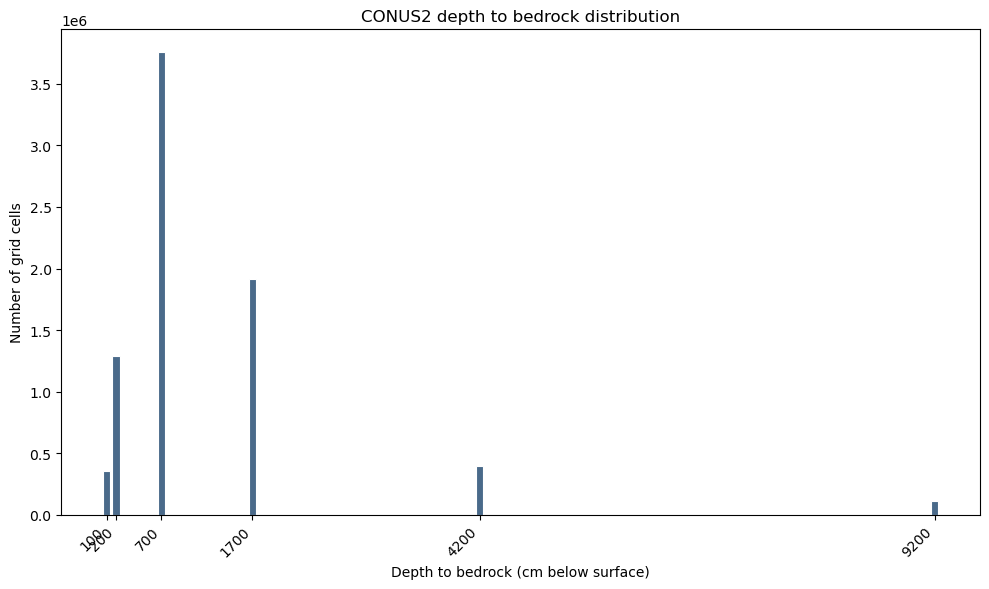

Saved /glade/derecho/scratch/bwest/drought-ensemble/analysis/conus2_flow_barrier_z/flow_barrier_depth_histogram.png


In [13]:
HIST_OUTPUT_PATH = DATA_DIR / "flow_barrier_depth_histogram.png"

depth_values = barrier_depth_cm[np.isfinite(barrier_depth_cm)]
unique_depths = np.sort(np.unique(depth_values))
counts = np.array([(depth_values == depth).sum() for depth in unique_depths], dtype=int)
x_positions = np.arange(len(unique_depths))
bar_width = 0.8

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x_positions,
    counts,
    width=bar_width,
    color="#4a6a8a",
    edgecolor="white",
    linewidth=0.8,
    align="center",
)
ax.set_xlabel("Depth to bedrock (cm below surface)")
ax.set_ylabel("Number of grid cells")
ax.set_title("CONUS2 depth to bedrock distribution")
ax.set_xticks(x_positions)
ax.set_xticklabels([f"{d:g}" for d in unique_depths], rotation=45, ha="right")
ax.set_xlim(-0.5, len(unique_depths) - 0.5)

for depth, count in zip(unique_depths, counts):
    print(f"  {depth:g} cm: {count:,} cells")

print(f"total cells with bedrock: {depth_values.size:,}")
fig.tight_layout()
fig.savefig(HIST_OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {HIST_OUTPUT_PATH}")